# POC: `floodsr tohr` on a Fathom tile

End-to-end run on one low-resolution Fathom depth tile.

> Note: keep this notebook on the `floodsr` Python API only. Do not switch it back to subprocess or CLI execution.

## IMPORTS

In [1]:
# Major imports for this notebook.
import importlib.metadata as metadata
import logging, os, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling

from floodsr.dem_sources.hrdem_mosaic import main_fetch_hrdem_for_lowres_tile
from floodsr.model_registry import fetch_model
from floodsr.tohr import tohr

PLOT_DPI = 300
min_depth_threshold = 0.01
warnings.filterwarnings("ignore", message="IProgress not found.*")

print(f"floodsr version: {metadata.version('floodsr')}")
print(f"rasterio version: {metadata.version('rasterio')}")
print(f"min_depth_threshold: {min_depth_threshold:.2f} m")


floodsr version: 0.1.3
rasterio version: 1.5.0
min_depth_threshold: 0.01 m


/opt/conda/envs/deploy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## PATHS

In [2]:
# Define source paths and output paths.
 
lores_fp = Path('/home/cefect/LS/10_IO/floodsr/fathom_1024/lores.tif')
assert lores_fp.is_file(), f"missing lores depth tile: {lores_fp}"

# Resolve the output directory from the environment and keep all notebook artifacts there.
out_dir = Path(os.getenv("OUT_DIR", "/home/cefect/LS/10_IO/2407_FHIMP/floodsr_fathom/proof"))
out_dir.mkdir(parents=True, exist_ok=True)
model_version = "ResUNet_16x_DEM"
lores_pp_fp = out_dir / f"{lores_fp.stem}_preprocessed.tif"
tohr_out_fp = out_dir / f"{lores_fp.stem}_tohr.tif"
tohr_log_fp = out_dir / f"{lores_fp.stem}_tohr_api.log"
hrdem_fp = out_dir / f"{lores_fp.stem}_fetched_hrdem.vrt"
tohr_result_fp = tohr_out_fp

print(f"out_dir:\n    {out_dir}")
print(f"lores_fp:\n    {lores_fp}")


out_dir:
    /home/cefect/LS/10_IO/2407_FHIMP/floodsr_fathom/proof
lores_fp:
    /home/cefect/LS/10_IO/floodsr/fathom_1024/lores.tif


### helpers

In [3]:

def _resolve_plot_shape(height, width, *, fig_w_in, fig_h_in, nrows=1, ncols=1, dpi=PLOT_DPI):
    """Return one coarse read shape sized to the rendered subplot footprint."""
    assert height > 0 and width > 0, (height, width)
    assert fig_w_in > 0 and fig_h_in > 0, (fig_w_in, fig_h_in)
    subplot_w_in = fig_w_in / ncols
    subplot_h_in = fig_h_in / nrows
    target_w = subplot_w_in * dpi
    target_h = subplot_h_in * dpi
    scale = min(target_h / float(height), target_w / float(width), 1.0)
    out_height = max(1, int(height * scale))
    out_width = max(1, int(width * scale))
    return (out_height, out_width), scale


def _read_plot_raster(ds, *, fig_w_in, fig_h_in, nrows=1, ncols=1):
    """Read one coarse raster preview using the subplot-sized render target."""
    out_shape, scale = _resolve_plot_shape(ds.height, ds.width, fig_w_in=fig_w_in, fig_h_in=fig_h_in, nrows=nrows, ncols=ncols)
    preview_ar = ds.read(1, out_shape=out_shape, masked=True, resampling=Resampling.nearest).astype(np.float32, copy=False)
    return preview_ar, out_shape, scale


def _mask_preview(preview_ar, *, nodata=None, extra_mask=None):
    """Apply nodata and custom masks to one coarse preview array."""
    mask_ar = np.ma.getmaskarray(preview_ar)
    if nodata is not None:
        mask_ar |= np.isclose(np.asarray(preview_ar), nodata)
    if extra_mask is not None:
        mask_ar |= np.asarray(extra_mask, dtype=bool)
    return np.ma.masked_array(np.asarray(preview_ar, dtype=np.float32), mask=mask_ar)


def _format_raster_note(ds, out_shape, scale, *, units="m"):
    """Build one short annotation showing the resampling parameters."""
    raw_res_x, raw_res_y = ds.res
    out_height, out_width = out_shape
    return "\n".join([
        f"raw: {ds.width:,}x{ds.height:,} px",
        f"res: {abs(raw_res_x):.2f}x{abs(raw_res_y):.2f} {units}",
        f"scale: {scale:.3f}",
        f"plot: {out_width:,}x{out_height:,} px",
    ])




def _get_notebook_logger(log_fp):
    """Return one file-backed logger for the notebook API run."""
    assert log_fp.parent.exists(), log_fp
    logger = logging.getLogger("fathom_tohr")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    logger.propagate = False
    handler = logging.FileHandler(log_fp, mode="w")
    handler.setFormatter(logging.Formatter("%(levelname)s:%(name)s:%(message)s"))
    logger.addHandler(handler)
    return logger

def _write_preprocessed_lores(src_fp, dst_fp):
    """Write the Fathom low-resolution raster as float32 meters blockwise."""
    with rasterio.open(src_fp) as src_ds:
        profile = src_ds.profile.copy()
        profile.update(dtype="float32", nodata=np.float32(-9999.0))
        with rasterio.open(dst_fp, "w", **profile) as dst_ds:
            for _, window in src_ds.block_windows(1):
                raw_block_ar = src_ds.read(1, window=window)
                mask_block_ar = (raw_block_ar == -32768) | (raw_block_ar == -32767)
                if src_ds.nodata is not None:
                    mask_block_ar |= np.isclose(raw_block_ar, src_ds.nodata)
                pp_block_ar = raw_block_ar.astype(np.float32)
                pp_block_ar /= np.float32(100.0)
                pp_block_ar[mask_block_ar] = np.float32(-9999.0)
                dst_ds.write(pp_block_ar, 1, window=window)


In [4]:
# Write the preprocessed lores raster blockwise so large source rasters stay off-heap.
_write_preprocessed_lores(lores_fp, lores_pp_fp)

print(f"wrote preprocessed tile:\n    {lores_pp_fp}")


wrote preprocessed tile:
    /home/cefect/LS/10_IO/2407_FHIMP/floodsr_fathom/proof/lores_preprocessed.tif


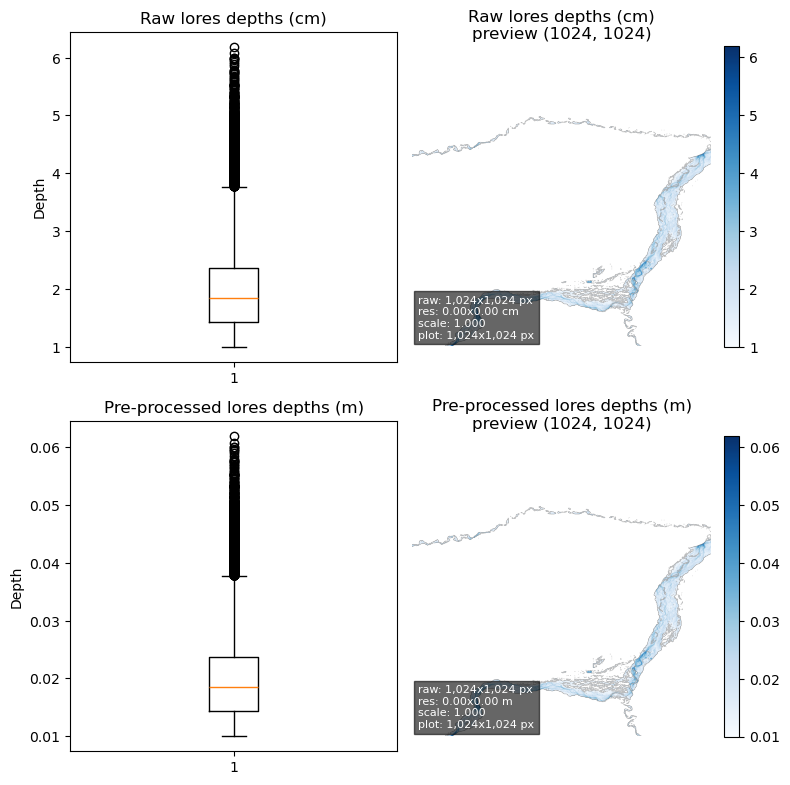

In [5]:
# Plot coarse lores previews with subplot-sized nearest-neighbor reads.
fig_w_in, fig_h_in = 8, 8

with rasterio.open(lores_fp) as ds_raw:
    raw_preview_ar, raw_preview_shape, raw_scale = _read_plot_raster(ds_raw, fig_w_in=fig_w_in, fig_h_in=fig_h_in, nrows=2, ncols=2)
    raw_nodata = ds_raw.nodata
    raw_note = _format_raster_note(ds_raw, raw_preview_shape, raw_scale, units="cm")

with rasterio.open(lores_pp_fp) as ds_pp:
    pp_preview_ar, pp_preview_shape, pp_scale = _read_plot_raster(ds_pp, fig_w_in=fig_w_in, fig_h_in=fig_h_in, nrows=2, ncols=2)
    pp_nodata = ds_pp.nodata
    pp_note = _format_raster_note(ds_pp, pp_preview_shape, pp_scale)

# Mask nodata and shallow water before plotting the depth rasters.
raw_mask_preview_ar = (np.asarray(raw_preview_ar) == -32768) | (np.asarray(raw_preview_ar) == -32767)
raw_mask_preview_ar |= np.asarray(raw_preview_ar) < (min_depth_threshold * 100.0)
pp_mask_preview_ar = np.asarray(pp_preview_ar) < min_depth_threshold
raw_show_ar = _mask_preview(raw_preview_ar, nodata=raw_nodata, extra_mask=raw_mask_preview_ar)
pp_show_ar = _mask_preview(pp_preview_ar, nodata=pp_nodata, extra_mask=pp_mask_preview_ar)

# Flatten valid preview values for compact distribution plots.
raw_val_ar = raw_show_ar.compressed()
pp_val_ar = pp_show_ar.compressed()

fig, axes = plt.subplots(2, 2, figsize=(fig_w_in, fig_h_in))

axes[0, 0].boxplot(raw_val_ar, vert=True)
axes[0, 0].set_title("Raw lores depths (cm)")
axes[0, 0].set_ylabel("Depth")

im0 = axes[0, 1].imshow(raw_show_ar, cmap="Blues")
axes[0, 1].set_title(f"Raw lores depths (cm)\npreview {raw_preview_shape}")
axes[0, 1].set_axis_off()
axes[0, 1].text(0.02, 0.02, raw_note, transform=axes[0, 1].transAxes, va="bottom", ha="left", color="white", fontsize=8, bbox={"facecolor": "black", "alpha": 0.6, "pad": 3})
fig.colorbar(im0, ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].boxplot(pp_val_ar, vert=True)
axes[1, 0].set_title("Pre-processed lores depths (m)")
axes[1, 0].set_ylabel("Depth")

im1 = axes[1, 1].imshow(pp_show_ar, cmap="Blues")
axes[1, 1].set_title(f"Pre-processed lores depths (m)\npreview {pp_preview_shape}")
axes[1, 1].set_axis_off()
axes[1, 1].text(0.02, 0.02, pp_note, transform=axes[1, 1].transAxes, va="bottom", ha="left", color="white", fontsize=8, bbox={"facecolor": "black", "alpha": 0.6, "pad": 3})
fig.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


## FETCH HRDEM

Progress bars are disabled in this notebook run. In captured notebook output, `tqdm` carriage returns expand into many lines. Single-line updates need a tty or widget-capable frontend, so this is mainly an environment/output-capture issue rather than a FloodSR API issue.

In [ ]:
# Run the fetch and ToHR flow through the FloodSR Python API only.
# Keep one file-backed logger so we can inspect cache and execution-path messages after the API calls return.
# Keep FloodSR progress bars off here because notebook capture turns carriage-return updates into many stdout lines.
logger = _get_notebook_logger(tohr_log_fp)
logger.info(f"starting notebook floodsr run with model_version={model_version}")

model_fp = fetch_model(model_version)
logger.info(f"resolved model_fp=\n    {model_fp}")

# Run the HRDEM fetch through the cache-aware path and keep the fetched VRT for plotting.
fetch_result = main_fetch_hrdem_for_lowres_tile(
    depth_lr_fp=lores_pp_fp,
    output_fp=hrdem_fp,
    force_tiling=True,
    use_cache=True,
    show_progress=False,
    logger=logger,
)
hrdem_fp = Path(fetch_result.dem_fp).resolve()


wrote API log:
    /home/cefect/LS/10_IO/2407_FHIMP/floodsr_fathom/proof/lores_tohr_api.log
cache diagnostics available: False
cache hits logged: 0
cache misses logged: 0
ToHR output:
    /home/cefect/LS/10_IO/2407_FHIMP/floodsr_fathom/proof/lores_tohr.vrt


# Plot the fetched HRDEM

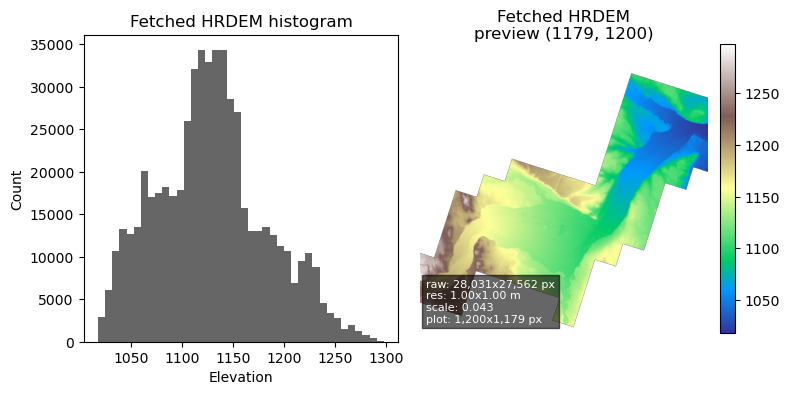

In [7]:
# Plot the fetched HRDEM with subplot-sized nearest-neighbor sampling.
fig_w_in, fig_h_in = 8, 4

with rasterio.open(hrdem_fp) as ds_dem:
    dem_plot_ar, dem_plot_shape, dem_plot_scale = _read_plot_raster(ds_dem, fig_w_in=fig_w_in, fig_h_in=fig_h_in, nrows=1, ncols=2)
    dem_plot_nodata = ds_dem.nodata
    dem_plot_note = _format_raster_note(ds_dem, dem_plot_shape, dem_plot_scale)

# Mask nodata before plotting the raster and its value distribution.
dem_plot_show_ar = _mask_preview(dem_plot_ar, nodata=dem_plot_nodata)
dem_plot_val_ar = dem_plot_show_ar.compressed()

fig, axes = plt.subplots(1, 2, figsize=(fig_w_in, fig_h_in))

axes[0].hist(dem_plot_val_ar, bins=40, color="0.4")
axes[0].set_title("Fetched HRDEM histogram")
axes[0].set_xlabel("Elevation")
axes[0].set_ylabel("Count")

im = axes[1].imshow(dem_plot_show_ar, cmap="terrain")
axes[1].set_title(f"Fetched HRDEM\npreview {dem_plot_shape}")
axes[1].set_axis_off()
axes[1].text(0.02, 0.02, dem_plot_note, transform=axes[1].transAxes, va="bottom", ha="left", color="white", fontsize=8, bbox={"facecolor": "black", "alpha": 0.6, "pad": 3})
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


# TOHR

In [ ]:

# Use hard windows so the model worker takes its raster-backed large-raster execution path.
result = tohr(
    model_version=model_version,
    model_fp=model_fp,
    depth_lr_fp=lores_pp_fp,
    dem_hr_fp=hrdem_fp,
    output_fp=tohr_out_fp,
    max_depth=10,
    min_depth_threshold=0.01,
    logger=logger,
    crs_policy="use-dem",
    window_method="hard",
    show_progress=False,
)
tohr_result_fp = Path(result["output_fp"]).resolve()

# Read the saved log to confirm the fetch mode and execution path that the notebook exercised.
tohr_log = tohr_log_fp.read_text()
cache_hit_count = tohr_log.count("tile cache hit:")
cache_miss_count = tohr_log.count("tile cache miss")
forced_tiled_fetch = "forcing tiled fetch via configuration" in tohr_log
used_windowed_execution = result.get("execution_path") == "windowed"
cache_lines_available = (cache_hit_count + cache_miss_count) > 0

assert forced_tiled_fetch, "expected forced tiled HRDEM fetch"
assert used_windowed_execution, f"expected windowed ToHR execution, got {result.get('execution_path')}"

print(f"wrote API log:\n    {tohr_log_fp}")
print(f"cache diagnostics available: {cache_lines_available}")
print(f"cache hits logged: {cache_hit_count}")
print(f"cache misses logged: {cache_miss_count}")
print(f"ToHR output:\n    {tohr_result_fp}")


In [8]:
# Summarize the Python API-driven ToHR run.
print(f"model_version: {model_version}")
print(f"tohr_result_fp:\n    {tohr_result_fp}")
print(f"tohr_log_fp:\n    {tohr_log_fp}")

model_version: ResUNet_16x_DEM
tohr_result_fp:
    /home/cefect/LS/10_IO/2407_FHIMP/floodsr_fathom/proof/lores_tohr.vrt
tohr_log_fp:
    /home/cefect/LS/10_IO/2407_FHIMP/floodsr_fathom/proof/lores_tohr_api.log


In [9]:
tohr_ok = tohr_result_fp.is_file() and hrdem_fp.is_file()

assert tohr_ok, f"missing output(s): tohr={tohr_result_fp.is_file()}, hrdem={hrdem_fp.is_file()}"


Output hires depths use the raw DEM grid, so their shape matches the DEM instead of the lores input.


/home/cefect/LS/10_IO/2407_FHIMP/tmp/ipykernel_17527/1166840371.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


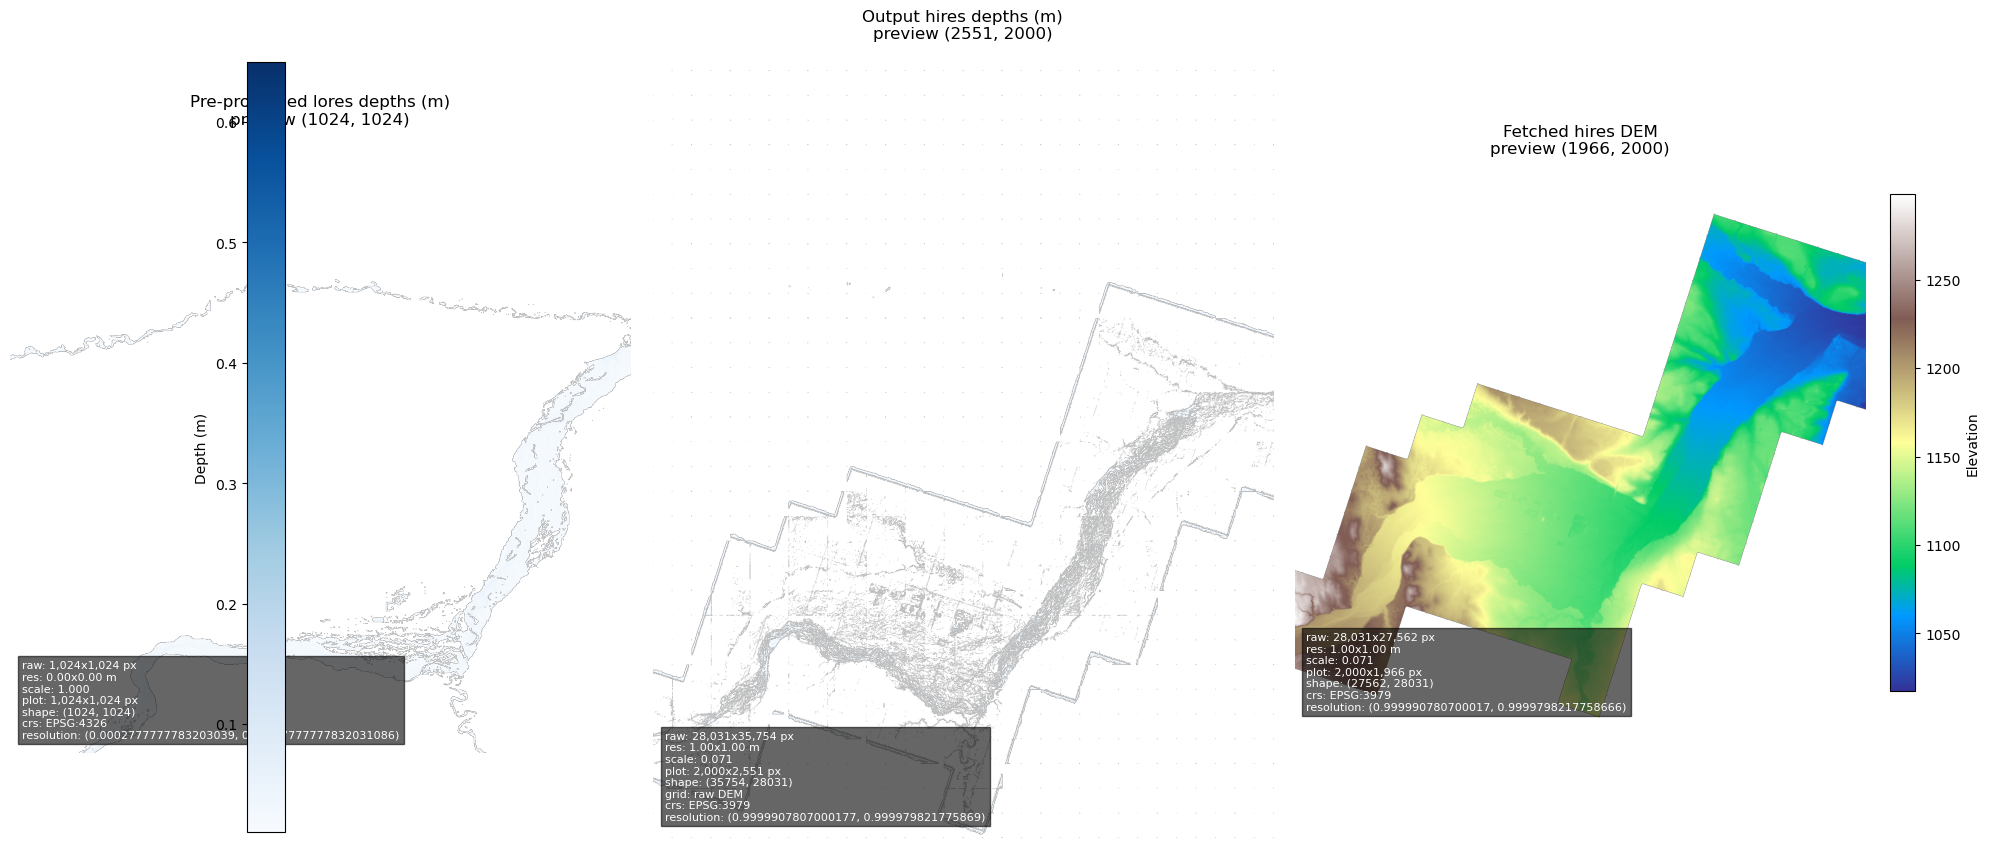

In [10]:

fig_w_in, fig_h_in = 20, 10

with rasterio.open(lores_pp_fp) as ds_lo:
    lo_ar, lo_preview_shape, lo_scale = _read_plot_raster(ds_lo, fig_w_in=fig_w_in, fig_h_in=fig_h_in, nrows=1, ncols=3)
    lo_nodata = ds_lo.nodata
    lo_shape = ds_lo.shape
    lo_crs = ds_lo.crs
    lo_res = ds_lo.res
    lo_note = _format_raster_note(ds_lo, lo_preview_shape, lo_scale)

with rasterio.open(tohr_result_fp) as ds_hi:
    hi_ar, hi_preview_shape, hi_scale = _read_plot_raster(ds_hi, fig_w_in=fig_w_in, fig_h_in=fig_h_in, nrows=1, ncols=3)
    hi_nodata = ds_hi.nodata
    hi_shape = ds_hi.shape
    hi_crs = ds_hi.crs
    hi_res = ds_hi.res
    hi_note = _format_raster_note(ds_hi, hi_preview_shape, hi_scale)

with rasterio.open(hrdem_fp) as ds_dem:
    dem_ar, dem_preview_shape, dem_scale = _read_plot_raster(ds_dem, fig_w_in=fig_w_in, fig_h_in=fig_h_in, nrows=1, ncols=3)
    dem_nodata = ds_dem.nodata
    dem_shape = ds_dem.shape
    dem_crs = ds_dem.crs
    dem_res = ds_dem.res
    dem_note = _format_raster_note(ds_dem, dem_preview_shape, dem_scale)

# The SR raster is written back onto the raw DEM grid after model-space inference.
shape_reason = "Output hires depths use the raw DEM grid, so their shape matches the DEM instead of the lores input."
print(shape_reason)

# Mask nodata and shallow water for clean depth plotting.
lo_show_ar = _mask_preview(lo_ar, nodata=lo_nodata, extra_mask=np.asarray(lo_ar) < min_depth_threshold)
hi_show_ar = _mask_preview(hi_ar, nodata=hi_nodata, extra_mask=np.asarray(hi_ar) < min_depth_threshold)
dem_show_ar = _mask_preview(dem_ar, nodata=dem_nodata)

# Use a common depth scale across the lores-preprocessed and hires-depth rasters.
depth_min = min(np.nanmin(lo_show_ar.filled(np.nan)), np.nanmin(hi_show_ar.filled(np.nan)))
depth_max = max(np.nanmax(lo_show_ar.filled(np.nan)), np.nanmax(hi_show_ar.filled(np.nan)))

fig, axes = plt.subplots(1, 3, figsize=(fig_w_in, fig_h_in))

im0 = axes[0].imshow(lo_show_ar, cmap="Blues", vmin=depth_min, vmax=depth_max)
axes[0].set_title(f"Pre-processed lores depths (m)\npreview {lo_preview_shape}")
axes[0].set_axis_off()

im1 = axes[1].imshow(hi_show_ar, cmap="Blues", vmin=depth_min, vmax=depth_max)
axes[1].set_title(f"Output hires depths (m)\npreview {hi_preview_shape}")
axes[1].set_axis_off()

im2 = axes[2].imshow(dem_show_ar, cmap="terrain")
axes[2].set_title(f"Fetched hires DEM\npreview {dem_preview_shape}")
axes[2].set_axis_off()

# Add shape, grid, and resampling annotations to each panel.
lo_meta_text = "\n".join([lo_note, f"shape: {lo_shape}", f"crs: {lo_crs}", f"resolution: {lo_res}"])
hi_meta_text = "\n".join([hi_note, f"shape: {hi_shape}", "grid: raw DEM", f"crs: {hi_crs}", f"resolution: {hi_res}"])
dem_meta_text = "\n".join([dem_note, f"shape: {dem_shape}", f"crs: {dem_crs}", f"resolution: {dem_res}"])
axes[0].text(0.02, 0.02, lo_meta_text, transform=axes[0].transAxes, ha="left", va="bottom", color="white", fontsize=8, bbox={"facecolor": "black", "alpha": 0.6, "pad": 3})
axes[1].text(0.02, 0.02, hi_meta_text, transform=axes[1].transAxes, ha="left", va="bottom", color="white", fontsize=8, bbox={"facecolor": "black", "alpha": 0.6, "pad": 3})
axes[2].text(0.02, 0.02, dem_meta_text, transform=axes[2].transAxes, ha="left", va="bottom", color="white", fontsize=8, bbox={"facecolor": "black", "alpha": 0.6, "pad": 3})

# Place depth colorbar on the far left and terrain colorbar on the right.
fig.colorbar(im0, ax=[axes[0], axes[1]], location="left", fraction=0.04, pad=0.04, label="Depth (m)")
fig.colorbar(im2, ax=axes[2], location="right", fraction=0.04, pad=0.04, label="Elevation")

fig.tight_layout()
plt.show()
